Imports

In [20]:
import os
import pandas as pd
import numpy as np
import time
import xlsxwriter
from xlsxwriter.utility import xl_rowcol_to_cell
import matplotlib.pyplot as plt

from utils import *

# change the font to LM Roman 12
import matplotlib.font_manager as fm
fm.fontManager.addfont('C://Users//hoel_m0//AppData//Local//Microsoft//Windows//Fonts//latin-modern-roman.mroman12-regular.otf')
plt.rcParams['font.family'] = 'Latin Modern Roman'
# make the font size larger
plt.rcParams.update({'font.size': 13})

# change the font to Frutiger
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Frutiger']

Read deterministic results

In [21]:
# Set functional units (more descriptive names can be added)
fu_list = ['FC', 'FH', 'ASK', 'Month', 'Year', 'Life']

# Header names
# headers = ['Parameter', 'ADP', 'CC', 'FETP', 'FEP', 'MEP', 'TEP', 'HHC', 'HHNC', 'IR', 'LU', 'MM', 'ODP', 'PM', 'POxF', 'WS']
headers = ['Parameter', 'ADP', 'FETP', 'TEP', 'HHC', 'HHNC', 'ODP', 'CC', 'ECF', 'FEP', 'MEP', 'IR', 'LU', 'MM', 'PM', 'POxF', 'WS']
impact_categories = headers[1:]

# Columns to read from the excel files
columns = 'B,F,G,K,L,P,T,U,Y,Z,AA,AB,AC,AD,AE,AF,AG'

overview_data = pd.read_excel(r"G:\Studenten\PLM\MariaHoeller\Overview_Individual_LCAs.xlsx")

# Read deterministic scores from reference case
output_folder_path = r"C:\Git_LYFE\airlyfe\projects\thesis_mc_2_lsa\outputs"
referencecase_path = os.path.join(output_folder_path, "D250-TFLH2-MHEP_eco.xlsx")


# read the deterministic results into a dataframe
deterministic_inputs = pd.read_excel(referencecase_path, sheet_name="Individual LCAs", usecols=columns, skiprows=3, nrows=34)
deterministic_outputs = pd.read_excel(referencecase_path, sheet_name="Summary", usecols="D:I", skiprows=30, nrows=16)

print(deterministic_outputs)

           per FC         per FH       per ASK     per Month      per Year  \
0      117.083193      66.908137  4.203843e-04  1.554396e+04  1.865276e+05   
1   326208.732640  186414.618520  1.171244e+00  4.330747e+07  5.196897e+08   
2      477.808655     273.047620  1.715560e-03  6.343388e+04  7.612065e+05   
3        0.000004       0.000003  1.614690e-11  5.970416e-04  7.164499e-03   
4        0.000376       0.000215  1.350605e-09  4.993944e-02  5.992732e-01   
5        0.000458       0.000262  1.643286e-09  6.076152e-02  7.291382e-01   
6    28484.711061   16277.818509  1.022736e-01  3.781630e+06  4.537956e+07   
7   374060.461173  213759.875797  1.343055e+00  4.966027e+07  5.959232e+08   
8        3.171451       1.812351  1.138702e-05  4.210418e+02  5.052502e+03   
9       44.520875      25.441814  1.598511e-04  5.910591e+03  7.092710e+04   
10     133.300682      76.175753  4.786127e-04  1.769700e+04  2.123640e+05   
11   43037.975451   24594.399146  1.545268e-01  5.713722e+06  6.

Store deterministic results and 'clean' names in a dictionary

In [22]:
# create a list of dictionaries to store the results
parameters = [{'name': list(deterministic_inputs['Name'])[i]} for i in range (len(list(deterministic_inputs['Name'])))]

parameters.append({'name': 'Maintenance Downtime, FC Check 1', 'x_nominal': 0.65})
parameters.append({'name': 'Maintenance Downtime, FC Check 2', 'x_nominal': 1.3})
parameters.append({'name': 'Maintenance Downtime, FC Check 3', 'x_nominal': 0.65})
parameters.append({'name': 'Maintenance Downtime, FC Check 4', 'x_nominal': 0.45})
parameters.append({'name': 'Maintenance Downtime, FC Check 5', 'x_nominal': 0.42})
parameters.append({'name': 'Maintenance Downtime, FC Check 6', 'x_nominal': 0.42})
parameters.append({'name': 'Maintenance Downtime, FC Check 7', 'x_nominal': 0.42})
parameters.append({'name': 'Maintenance Downtime, Fuel Cell Replacement', 'x_nominal': 24})
parameters.append({'name': 'Maintenance Interval, FC Check 1', 'x_nominal': 29333})
parameters.append({'name': 'Maintenance Interval, FC Check 2', 'x_nominal': 3178})
parameters.append({'name': 'Maintenance Interval, FC Check 3', 'x_nominal': 27500})
parameters.append({'name': 'Maintenance Interval, FC Check 4', 'x_nominal': 16500})
parameters.append({'name': 'Maintenance Interval, FC Check 5', 'x_nominal': 6875})
parameters.append({'name': 'Maintenance Interval, FC Check 6', 'x_nominal': 8250})
parameters.append({'name': 'Maintenance Interval, FC Check 7', 'x_nominal': 24750})
parameters.append({'name': 'Maintenance Interval, Fuel Cell Replacement', 'x_nominal': 20000})

for parameter in parameters:
    parameter['name_plots'] = parameter['name']
    if 'Maintenance' in parameter['name']:
        parameter['x_changed'] = parameter['x_nominal'] * 1.1
        parameter['name_plots_short'] = parameter['name'][12:]
        if 'Fuel Cell Replacement' in parameter['name']:
            parameter['name_plots_short'] = parameter['name_plots_short'][:-21] + 'FC Replacement'

# loop through the parameters and store the results in the dictionaries
for param_idx, parameter in enumerate(parameters):
    
    # create a dictionary to store the nominal values of the inputs and outputs
    if 'Maintenance' not in parameter['name']:
        parameter['x_nominal'] = {}
    parameter['y_nominal'] = {}
    
    # find the correct data via iloc from the deterministic inputs
    for impcat_idx, impact_category in enumerate(impact_categories):
        
        # store the nominal values of the inputs
        if 'Maintenance' not in parameter['name']:
            parameter['x_nominal'][impact_category] = deterministic_inputs.iloc[param_idx][impcat_idx+1]
        
        # store the nominal values of the outputs
        parameter['y_nominal'][impact_category] = {}
        for fu_idx, fu in enumerate(fu_list):
            parameter['y_nominal'][impact_category][fu] = deterministic_outputs.iloc[impcat_idx][fu_idx]
    
    if 'Maintenance' not in parameter['name']:
        parameter['name_plots'] = overview_data.loc[overview_data['Demand name'].str.lower() == parameter['name'].lower(), 'Name for Plots'].values[0]
        parameter['name_plots_short'] = overview_data.loc[overview_data['Demand name'].str.lower() == parameter['name'].lower(), 'Name for Plots (Short)'].values[0]
    print(parameter['name_plots_short'],"\n Nominal inputs: ",parameter['x_nominal'])


Aircraft Production 
 Nominal inputs:  {'ADP': 14783.01487, 'FETP': 72954919.86, 'TEP': 23746.08774, 'HHC': 0.009849102, 'HHNC': 0.146814663, 'ODP': 0.049057927, 'CC': 2411050.104, 'ECF': 27546465.58, 'FEP': 113.9725846, 'MEP': 2145.719409, 'IR': 59679.2676, 'LU': 7354409.102, 'MM': 32.67626261, 'PM': 0.193294277, 'POxF': 8444.683361, 'WS': 785034.6171}
FC Stack Production 
 Nominal inputs:  {'ADP': 779.5415499, 'FETP': 261066.6073, 'TEP': 906.5551947, 'HHC': 1.85508e-05, 'HHNC': 0.000338189, 'ODP': 0.016558701, 'CC': 12756.61345, 'ECF': 185387.5864, 'FEP': 1.280127424, 'MEP': 62.54613965, 'IR': 209.9476775, 'LU': 103906.155, 'MM': 0.673226879, 'PM': 0.001967767, 'POxF': 225.285143, 'WS': 4915.941689}
BoP Production 
 Nominal inputs:  {'ADP': 13.26156091, 'FETP': 14502.93902, 'TEP': 11.7049002, 'HHC': 4.57904e-06, 'HHNC': 0.000130313, 'ODP': 0.002911968, 'CC': 689.6459632, 'ECF': 8043.769691, 'FEP': 0.070568278, 'MEP': 0.918801828, 'IR': 17.66154134, 'LU': 4543.420239, 'MM': 0.15472848

Read LSA results

In [23]:
# DataFrames to store inputs and outputs
sensitivity_df = pd.DataFrame()
elasticity_df = pd.DataFrame()
i = 0

inputs_list = []
outputs_list = []
filename_list = []

# Process all "_eco.xlsx" files
for file in os.listdir(output_folder_path):
    if file.endswith("_eco.xlsx") and not file.endswith("_vs_referencecase_eco.xlsx") and not file.startswith("D250-TF"):
        i += 1
        
        # read the data from the file
        file_path = os.path.join(output_folder_path, file)
        inputs_list.append(pd.read_excel(file_path, sheet_name="Individual LCAs", usecols=columns, skiprows=3, nrows=34))
        outputs_list.append(pd.read_excel(file_path, sheet_name="Summary", usecols="D:I", skiprows=30, nrows=16))
        filename_list.append(file)
        
print(f"Successfully read the data from {i} files in the folder {output_folder_path}")


Successfully read the data from 49 files in the folder C:\Git_LYFE\airlyfe\projects\thesis_mc_2_lsa\outputs


Store LSA results in the dictionary and calculate sensitivity/elasticity

Sensitivity = $\frac{\Delta y}{\Delta x}$

Elasticity = $\frac{x_\text{nominal} \Delta y}{y_\text{nominal} \Delta x}$

In [24]:
for file_idx, (input, filename) in enumerate(zip(inputs_list, filename_list)):
    
    if 'maintenance_downtime' in filename:
        for parameter in parameters:
            if filename.endswith('0_eco.xlsx'):
                if 'Maintenance Downtime, FC Check 1' in parameter['name']:
                    parameter['file_idx'] = file_idx
            if filename.endswith('1_eco.xlsx'):
                if 'Maintenance Downtime, FC Check 2' in parameter['name']:
                    parameter['file_idx'] = file_idx
            if filename.endswith('2_eco.xlsx'):
                if 'Maintenance Downtime, FC Check 3' in parameter['name']:
                    parameter['file_idx'] = file_idx
            if filename.endswith('3_eco.xlsx'):
                if 'Maintenance Downtime, FC Check 4' in parameter['name']:
                    parameter['file_idx'] = file_idx
            if filename.endswith('4_eco.xlsx'):
                if 'Maintenance Downtime, FC Check 5' in parameter['name']:
                    parameter['file_idx'] = file_idx
            if filename.endswith('5_eco.xlsx'):
                if 'Maintenance Downtime, FC Check 6' in parameter['name']:
                    parameter['file_idx'] = file_idx
            if filename.endswith('6_eco.xlsx'):
                if 'Maintenance Downtime, FC Check 7' in parameter['name']:
                    parameter['file_idx'] = file_idx
            if filename.endswith('7_eco.xlsx'):
                if 'Maintenance Downtime, Fuel Cell Replacement' in parameter['name']:
                    parameter['file_idx'] = file_idx
                
    elif 'maintenance_interval' in filename:
        for parameter in parameters:
            if filename.endswith('0_eco.xlsx'):
                if 'Maintenance Interval, FC Check 1' in parameter['name']:
                    parameter['file_idx'] = file_idx
            if filename.endswith('1_eco.xlsx'): 
                if 'Maintenance Interval, FC Check 2' in parameter['name']:
                    parameter['file_idx'] = file_idx
            if filename.endswith('2_eco.xlsx'):
                if 'Maintenance Interval, FC Check 3' in parameter['name']:
                    parameter['file_idx'] = file_idx
            if filename.endswith('3_eco.xlsx'):
                if 'Maintenance Interval, FC Check 4' in parameter['name']:
                    parameter['file_idx'] = file_idx
            if filename.endswith('4_eco.xlsx'):
                if 'Maintenance Interval, FC Check 5' in parameter['name']:
                    parameter['file_idx'] = file_idx
            if filename.endswith('5_eco.xlsx'): 
                if 'Maintenance Interval, FC Check 6' in parameter['name']:
                    parameter['file_idx'] = file_idx
            if filename.endswith('6_eco.xlsx'):
                if 'Maintenance Interval, FC Check 7' in parameter['name']:
                    parameter['file_idx'] = file_idx
            if filename.endswith('7_eco.xlsx'):
                if 'Maintenance Interval, Fuel Cell Replacement' in parameter['name']:
                    parameter['file_idx'] = file_idx   
        
    else:
        
        # loop through the parameters and store the results in the dictionaries
        for param_idx, parameter in enumerate(parameters):
                        
            # create a dictionary to store the changed values of the inputs
            changed_inputs = {}          
            
            # find the changed input values
            if parameter['name'] in list(input['Name']):
                for impcat_idx, impact_category in enumerate(impact_categories):
                    changed_inputs[impact_category] = input.iloc[param_idx][impcat_idx+1]
                
                # compare the changed inputs to the nominal inputs and find the changed ones        
                if changed_inputs != parameter['x_nominal']:
                    parameter['file_idx'] = file_idx
                    parameter['x_changed'] = changed_inputs
                    parameter['file'] = filename
                
           
# loop over the parameters and find the correct outputs
for parameter in parameters:
        
    parameter['y_changed'] = {}
    parameter['sensitivity'] = {}
    parameter['elasticity'] = {}
    
    # print(parameter['name_plots'])
    
    # print(parameter['name'])
    for impcat_idx, impact_category in enumerate(impact_categories):
        parameter['sensitivity'][impact_category] = {}
        parameter['elasticity'][impact_category] = {}
        
        # store the changed values of the outputs
        parameter['y_changed'][impact_category] = {}
        
        for fu_idx, fu in enumerate(fu_list):
            parameter['y_changed'][impact_category][fu] = outputs_list[parameter['file_idx']].iloc[impcat_idx][fu_idx]
        
        # calculate the sensitivity and elasticity
        for fu in fu_list:
            if 'Maintenance' in parameter['name']:
                delta_x = parameter['x_changed'] - parameter['x_nominal']
                delta_y = parameter['y_changed'][impact_category][fu] - parameter['y_nominal'][impact_category][fu]
                
                sensitivity = delta_y / delta_x
                elasticity = parameter['x_nominal'] * delta_y / parameter['y_nominal'][impact_category][fu] * delta_x
                
            else:     
                delta_x = parameter['x_changed'][impact_category] - parameter['x_nominal'][impact_category]
                delta_y = parameter['y_changed'][impact_category][fu] - parameter['y_nominal'][impact_category][fu]
            
                sensitivity = delta_y / delta_x
                elasticity = parameter['x_nominal'][impact_category] * delta_y / parameter['y_nominal'][impact_category][fu] * delta_x
            
            parameter['sensitivity'][impact_category][fu] = sensitivity
            parameter['elasticity'][impact_category][fu] = elasticity
        
    print(parameter['name_plots'], "\n Sensitivity: ", parameter['sensitivity'], "\n Elasticity: ", parameter['elasticity'])
       


Aircraft Production 
 Sensitivity:  {'ADP': {'FC': 1.8061582690220803e-05, 'FH': 1.032449416767667e-05, 'ASK': 6.487012409603321e-11, 'Month': 0.003413837741322643, 'Year': 0.04096605289587171, 'Life': 1.0241513223967929}, 'FETP': {'FC': 1.8061692542609982e-05, 'FH': 1.0324462024613373e-05, 'ASK': 6.486988300205664e-11, 'Month': 0.003382302866390458, 'Year': 0.040587634396685474, 'Life': 1.014690859917137}, 'TEP': {'FC': 1.8061201466752598e-05, 'FH': 1.032463900010583e-05, 'ASK': 6.487118362877782e-11, 'Month': 0.00353433754087066, 'Year': 0.042412050490447925, 'Life': 1.060301262261198}, 'HHC': {'FC': 1.8060289959457107e-05, 'FH': 1.0323541750078511e-05, 'ASK': 6.486405194296319e-11, 'Month': 0.0033426438805685015, 'Year': 0.04011172656682202, 'Life': 1.0027931641705508}, 'HHNC': {'FC': 1.8060704828048353e-05, 'FH': 1.0323890517106447e-05, 'ASK': 6.48662893014356e-11, 'Month': 0.003379821781508943, 'Year': 0.04055786137810733, 'Life': 1.0139465344526832}, 'ODP': {'FC': 1.8052132408746

Function to make the report look nice

In [25]:
# funtion to make the report look nice in the LYFE format
def initialize_report(workbook, writer):
    # In line with the DLR template, the font is set
    workbook.formats[0].set_font_name('Frutiger 45 Light')

    formats_dict = {
        'title': {
            'font_size': 18,
            'bold': True,
            'font_color': '#7b7b84',
            'align': 'center',
            'valign': 'vcenter',
            'bg_color': 'white',
            'bottom': 2,
        },
        'white': {
            'bg_color': 'white',
        },
        'white+blackbottom': {
            'bg_color': 'white',
            'bottom': 2,
        }
    }

    formats = {key: workbook.add_format(val) for key, val in formats_dict.items()}

    worksheets = ['FC', 'FH', 'ASK', 'Month', 'Year', 'Life']
    worksheet_titles = ['LSA Results per Flight Cycle', 'LSA Results per Flight Hour', 
                        'LSA Results per Available Seat Kilometer', 'LSA Results per Month', 
                        'LSA Results per Year', 'LSA Results per Life']
    
    worksheets = ['Sensitivity', 'Elasticity']
    worksheet_titles = worksheets

    for i, worksheet in enumerate(worksheets):
        ws = workbook.add_worksheet(worksheet)
        ws.set_row(0, 47.25, formats['white+blackbottom'])
        ws.set_row(1, 15, formats['white'])
        ws.set_column(0, 0, 2)
        ws.set_column(1, 2, 16)
        ws.set_column(3, 10000, 13)

        ws.merge_range('J1:G1', worksheet_titles[i], formats['title'])

        dpath_logos = r"C:\Git_LYFE\airlyfe\airlyfe\otherstuff"
        ws.insert_image('A1', filename=os.path.join(dpath_logos, 'logos.png'), options={'x_scale': 0.88886})

        writer.sheets[worksheet] = ws

    return workbook, writer

def apply_conditional_formatting(worksheet, dataframe, startrow, startcol):
    # Calculate the number of rows and columns in the DataFrame
    number_of_rows = dataframe.shape[0]
    number_of_cols = dataframe.shape[1]

    # The data starts from the cell after the header (which is at startrow)
    data_start_row = startrow + 1  # +1 to skip the column headers
    data_start_col = startcol + 1  # +1 to skip the index column ('Parameter')

    # The data ends at:
    data_end_row = data_start_row + number_of_rows - 1
    data_end_col = data_start_col + number_of_cols - 1

    # Create the cell range string
    start_cell = xl_rowcol_to_cell(data_start_row, data_start_col)
    end_cell = xl_rowcol_to_cell(data_end_row, data_end_col)

    cell_range = f'{start_cell}:{end_cell}'

    # Define your conditional formatting rule
    conditional_format = {
        'type': '3_color_scale',  # You can change this to '2_color_scale' or 'data_bar' as needed
        # For more advanced rules, specify 'min_type', 'mid_type', 'max_type', etc.
        'min_type': 'percentile',
        'min_value': 15,
        'min_color': '#73a237',
        'mid_type': 'percentile',
        'mid_value': 50,
        'mid_color': '#e0b02e',
        'max_type': 'percentile',
        'max_value': 85,
        'max_color': '#a44a3f'
    }

    # Apply the conditional formatting
    worksheet.conditional_format(cell_range, conditional_format)


Write the report

In [26]:
# set the output filename
output_file = os.path.join(output_folder_path, "lsa_results.xlsx")

# create the excel writer
writer = pd.ExcelWriter(output_file, engine='xlsxwriter')
workbook = writer.book
workbook, writer = initialize_report(workbook, writer)

# create lists for the sensitivity and elasticity DataFrames
sensitivity_dataframes = []
elasticity_dataframes = []

# write the parameter results to the excel file
with writer as writer:
    # for fu in fu_list:
    #     sensitivity_df = pd.DataFrame()
    #     elasticity_df = pd.DataFrame()
    #     for parameter in parameters[:-1]: ## once everything is working, remove the [:-1]!!
    #         for impact_category in impact_categories:
    #             sensitivity_df.at[parameter['name'], impact_category] = parameter['sensitivity'][impact_category][fu]
    #             elasticity_df.at[parameter['name'], impact_category] = parameter['elasticity'][impact_category][fu]
    #     sensitivity_df.to_excel(writer, sheet_name=fu, startrow=4, startcol=3, index_label='Parameter')
    #     elasticity_df.to_excel(writer, sheet_name=fu, startrow=4, startcol=3+len(impact_categories)+2, index_label='Parameter')
    
    worksheet_sensitivity = writer.sheets['Sensitivity']
    worksheet_elasticity = writer.sheets['Elasticity']
    
    # loop through each FU, create the sensitivity and elasticity DataFrames and write them to the file
    for fu_idx, fu in enumerate(fu_list):
        sensitivity_df = pd.DataFrame()
        elasticity_df = pd.DataFrame()

        # loop through the parameters and store the results for each FU in the correct DataFrames
        for parameter in parameters:
            for impact_category in impact_categories:
                sensitivity_df.at[parameter['name_plots_short'], impact_category] = parameter['sensitivity'][impact_category][fu]
                elasticity_df.at[parameter['name_plots_short'], impact_category] = parameter['elasticity'][impact_category][fu]
                
        sensitivity_df['Average'] = sensitivity_df.mean(axis=1)
        elasticity_df['Average'] = elasticity_df.mean(axis=1)
                           
        # write the sensitivity to the excel file
        worksheet_sensitivity.write(3+fu_idx*(3+len(parameters)), 1, fu)
        sensitivity_df.to_excel(writer, sheet_name='Sensitivity', startrow=4+fu_idx*(3+len(parameters)), startcol=1, index_label='Parameter')
        sensitivity_dataframes.append(sensitivity_df)
        
        # write the elasticity to the excel file
        worksheet_elasticity.write(3+fu_idx*(3+len(parameters)), 1, fu)
        elasticity_df.to_excel(writer, sheet_name='Elasticity', startrow=4+fu_idx*(3+len(parameters)), startcol=1, index_label='Parameter')
        elasticity_dataframes.append(elasticity_df)
        
        # apply conditional formatting
        apply_conditional_formatting(worksheet_sensitivity, sensitivity_df, startrow=4+fu_idx*(3+len(parameters)), startcol=1)
        apply_conditional_formatting(worksheet_elasticity, elasticity_df, startrow=4+fu_idx*(3+len(parameters)), startcol=1)

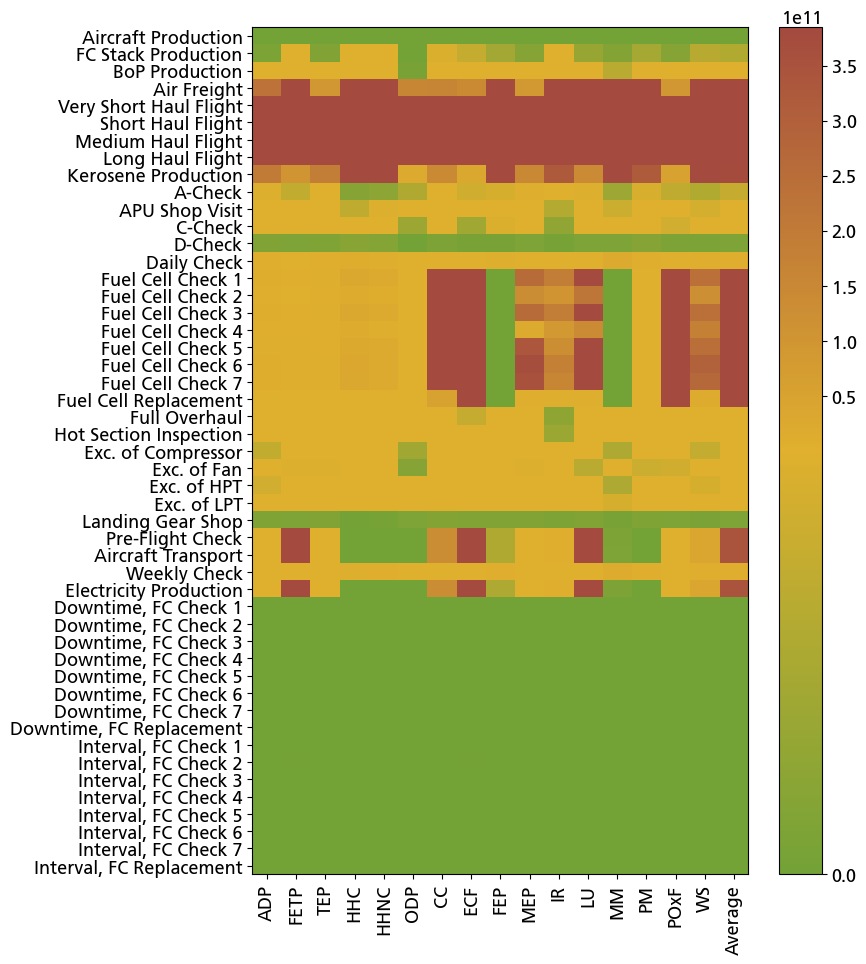

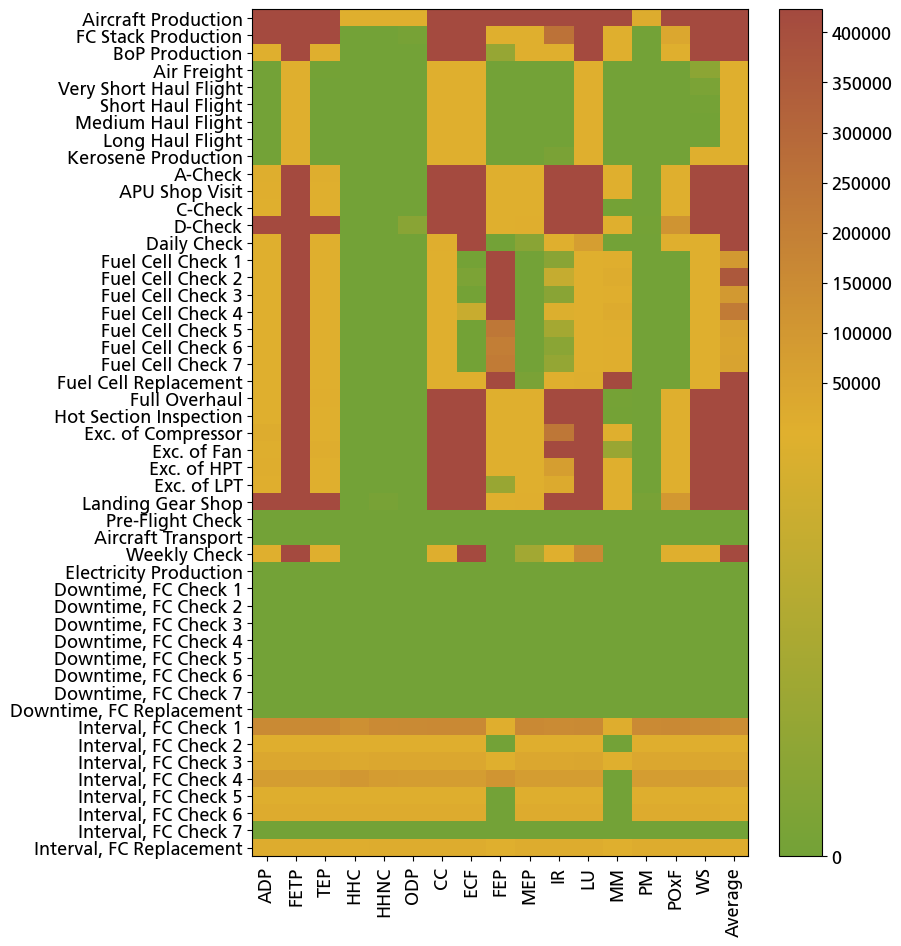

In [27]:
# custom define colours
blue = '#00668d'
light_blue = '#0099CE'
green = '#73a237'
light_green = '#9cc045'
gray = '#686867'
light_gray = '#b2b2b2'
yellow = '#e0b02e'
light_yellow = '#ffce44'
red = '#a44a3f'
purple = '#49111c'
pink = '#d88c9a'


colors = [green, yellow, red]
positions = [0, 0.5, 1]


from matplotlib.colors import LinearSegmentedColormap, Normalize, TwoSlopeNorm
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", list(zip(positions, colors)))

# Function to create smooth normalization based on quantiles
def smooth_quantile_normalizer(data, quantiles=[15, 50, 85]):
    # Calculate the actual quantile values for the data
    q15, q50, q85 = np.percentile(data, quantiles)
    # Set up a Normalize instance that smoothly transitions between quantiles
    norm = TwoSlopeNorm(vmin=q15, vcenter=q50, vmax=q85)
    return norm

for i, sensitivity_df in enumerate(sensitivity_dataframes):
    norm = smooth_quantile_normalizer(sensitivity_df.values.flatten())
    # Create a heatmap
    plt.figure(figsize=(8, 11))
    plt.imshow(sensitivity_df, cmap=custom_cmap, aspect='auto', norm=norm)
    plt.colorbar()
    # plt.title(f'Sensitivity, per {fu_list[i]}')
    # set the index as the y labels
    plt.yticks(ticks=np.arange(len(sensitivity_df.index)), labels=sensitivity_df.index)
    # set the impact categories as the x labels
    plt.xticks(ticks=np.arange(len(sensitivity_df.columns)), labels=sensitivity_df.columns, rotation=90)
    if fu_list[i] == 'Life':
        # plt.savefig(f"sensitivity_{fu_list[i]}.png", dpi=600, bbox_inches='tight')
        plt.show()
    plt.close()
    
for i, elasticity_df in enumerate(elasticity_dataframes):
    norm = smooth_quantile_normalizer(elasticity_df.values.flatten())
    # Create a heatmap
    plt.figure(figsize=(8, 11))
    plt.imshow(elasticity_df, cmap=custom_cmap, aspect='auto', norm=norm)
    plt.colorbar()
    # plt.title(f'Elasticity, per {fu_list[i]}')
    plt.yticks(ticks=np.arange(len(elasticity_df.index)), labels=elasticity_df.index)
    plt.xticks(ticks=np.arange(len(elasticity_df.columns)), labels=elasticity_df.columns, rotation=90)
    if fu_list[i] == 'Life':
        # plt.savefig(f"elasticity_{fu_list[i]}.png", dpi=600, bbox_inches='tight')
        plt.show()
    plt.close()
    


Plot diagnostic diagram

In [28]:
import json
# read Monte Carlo results
mcs_results_folder = r"C:\Git_LYFE\airlyfe\productive_results"

# create and sort a list of the files in the folder
file_list = [file for file in os.listdir(mcs_results_folder) if file.startswith("lca_") and file.endswith("_monte_carlo.json")]
file_list.sort(key=lambda x: int(x.split('_')[1]))
file_list = file_list

parameters_sliced = [parameters[0]] + parameters[3:14] + parameters[23:34] + parameters[14:22] + parameters[1:3]
for parameter, file in zip(parameters_sliced, file_list):
    # read the data from the file
    file_path = os.path.join(mcs_results_folder, file)
    with open(file_path) as f:
        data = json.load(f)
            
    # store the results in the parameter dictionary
    parameter['mean'] = {}
    parameter['std'] = {}
    for impact_category in impact_categories:
        if 'FC Check' not in parameter['name']:
            if impact_category == 'ADP': impact_category_mcs = 'acidification no LT [mol H+-Eq]'
            if impact_category == 'FETP': impact_category_mcs = 'ecotoxicity: freshwater no LT [CTUe]'
            if impact_category == 'TEP': impact_category_mcs = 'eutrophication: terrestrial no LT [mol N-Eq]'
            if impact_category == 'HHC': impact_category_mcs = 'human toxicity: carcinogenic no LT [CTUh]'
            if impact_category == 'HHNC': impact_category_mcs = 'human toxicity: non-carcinogenic no LT [CTUh]'
            if impact_category == 'ODP': impact_category_mcs = 'ozone depletion no LT [kg CFC-11-Eq]'
            if impact_category == 'CC': impact_category_mcs = 'climate change no LT [kg CO2-Eq]'
            if impact_category == 'ECF': impact_category_mcs = 'energy resources: non-renewable no LT [MJ, net calorific value]'
            if impact_category == 'FEP': impact_category_mcs = 'eutrophication: freshwater no LT [kg P-Eq]'
            if impact_category == 'MEP': impact_category_mcs = 'eutrophication: marine no LT [kg N-Eq]'
            if impact_category == 'IR': impact_category_mcs = 'ionising radiation: human health no LT [kBq U235-Eq]'
            if impact_category == 'LU': impact_category_mcs = 'land use no LT [dimensionless]'
            if impact_category == 'MM': impact_category_mcs = 'material resources: metals/minerals no LT [kg Sb-Eq]'
            if impact_category == 'PM': impact_category_mcs = 'particulate matter formation no LT [disease incidence]'
            if impact_category == 'POxF': impact_category_mcs = 'photochemical oxidant formation: human health no LT [kg NMVOC-Eq]'
            if impact_category == 'WS': impact_category_mcs = 'water use no LT [m3 world eq. deprived]'    
        else:
            if impact_category == 'ADP': impact_category_mcs = 'acidification [mol H+-Eq]'
            if impact_category == 'FETP': impact_category_mcs = 'ecotoxicity: freshwater [CTUe]'
            if impact_category == 'TEP': impact_category_mcs = 'eutrophication: terrestrial [mol N-Eq]'
            if impact_category == 'HHC': impact_category_mcs = 'human toxicity: carcinogenic [CTUh]'
            if impact_category == 'HHNC': impact_category_mcs = 'human toxicity: non-carcinogenic [CTUh]'
            if impact_category == 'ODP': impact_category_mcs = 'ozone depletion [kg CFC-11-Eq]'
            if impact_category == 'CC': impact_category_mcs = 'climate change [kg CO2-Eq]'
            if impact_category == 'ECF': impact_category_mcs = 'energy resources: non-renewable [MJ, net calorific value]'
            if impact_category == 'FEP': impact_category_mcs = 'eutrophication: freshwater [kg P-Eq]'
            if impact_category == 'MEP': impact_category_mcs = 'eutrophication: marine [kg N-Eq]'
            if impact_category == 'IR': impact_category_mcs = 'ionising radiation: human health [kBq U235-Eq]'
            if impact_category == 'LU': impact_category_mcs = 'land use [dimensionless]'
            if impact_category == 'MM': impact_category_mcs = 'material resources: metals/minerals [kg Sb-Eq]'
            if impact_category == 'PM': impact_category_mcs = 'particulate matter formation [disease incidence]'
            if impact_category == 'POxF': impact_category_mcs = 'photochemical oxidant formation: human health [kg NMVOC-Eq]'
            if impact_category == 'WS': impact_category_mcs = 'water use [m3 world eq. deprived]' 
            
        parameter['mean'][impact_category] = data['mc_statistics'][impact_category_mcs]['mean']
        parameter['std'][impact_category] = data['mc_statistics'][impact_category_mcs]['std']  


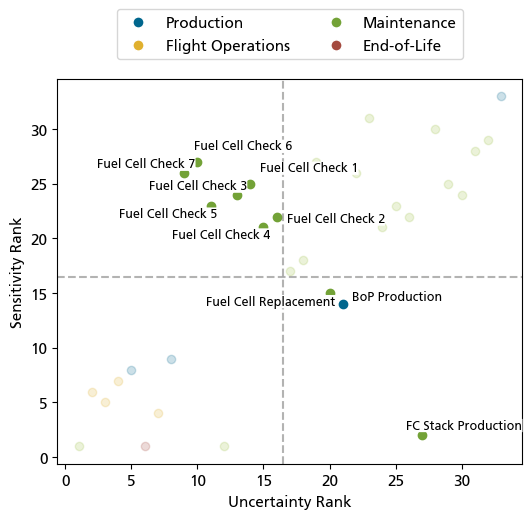

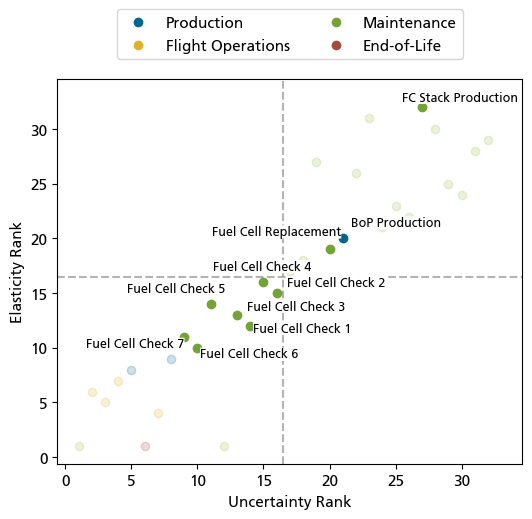

In [29]:
from adjustText import adjust_text

# Define color mapping for lifecycle phases
colors = {
    'Aircraft Production': blue,
    'BoP Production': blue,
    'Air Freight': blue,
    'Kerosene Production': blue,
    'Very Short Haul Flight': yellow,
    'Short Haul Flight': yellow,
    'Medium Haul Flight': yellow,
    'Long Haul Flight': yellow,
    'A-Check': light_green,
    'APU Shop Visit': light_green,
    'C-Check': light_green,
    'D-Check': light_green,
    'Daily Check': light_green,
    'Full Overhaul': light_green,
    'Hot Section Inspection': light_green,
    'Exc. of Compressor': light_green,
    'Exc. of Fan': light_green,
    'Exc. of HPT': light_green,
    'Exc. of LPT': light_green,
    'Landing Gear Shop': light_green,
    'Pre-Flight Check': light_green,
    'Aircraft Transport': light_green,
    'Weekly Check': light_green,
    'Electricity Production': red,
    'Fuel Cell Check 1': green,
    'Fuel Cell Check 2': green,
    'Fuel Cell Check 3': green,
    'Fuel Cell Check 4': green,
    'Fuel Cell Check 5': green,
    'Fuel Cell Check 6': green,
    'Fuel Cell Check 7': green,
    'Fuel Cell Replacement': green,
    'FC Stack Production': green,
}

# Map lifecycle phases to a color legend
lifecycle_phase_colors = {
    'Production': blue,
    'Flight Operations': yellow,
    'Maintenance': green,
    'End-of-Life': red
}

# change fontsize to 11
c

# Plotting loop
for impact_category in impact_categories[:1]:
    sensitivity_values = [param['sensitivity'][impact_category]['FC'] for param in parameters_sliced]
    elasticity_values = [param['elasticity'][impact_category]['FC'] for param in parameters_sliced]
    uncertainty_values = [param['std'][impact_category] for param in parameters_sliced]
    
    sensitivity_ranks = pd.Series(sensitivity_values).rank(method="min").tolist()
    elasticity_ranks = pd.Series(elasticity_values).rank(method="min").tolist()
    uncertainty_ranks = pd.Series(uncertainty_values).rank(method="min").tolist()
    
    plt.figure(figsize=(6, 5))

    # create a red line in the middle of x and y axis that is transparent
    plt.axvline(x=16.5, color=gray, linestyle='--', alpha=0.5)
    plt.axhline(y=16.5, color=gray, linestyle='--', alpha=0.5)
    
    # Scatter plot with ranks and assign colors
    texts = []
    for i, parameter in enumerate(parameters_sliced):
        color = colors.get(parameter['name_plots_short'], 'black')
        if 'Fuel Cell' in parameter['name_plots_short'] or 'FC' in parameter['name_plots_short'] or 'BoP' in parameter['name_plots_short']:
            plt.scatter(uncertainty_ranks[i], sensitivity_ranks[i], c=color)
            text = plt.text(uncertainty_ranks[i], sensitivity_ranks[i], parameter['name_plots_short'], fontsize=9, ha='center', va='bottom',
                            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.01'))
            texts.append(text)
        else:
            plt.scatter(uncertainty_ranks[i], elasticity_ranks[i], c=color, alpha=0.2)
    
    # Add legend above plot
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=phase, markersize=8, markerfacecolor=color)
               for phase, color in lifecycle_phase_colors.items()]
    plt.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=2)

    plt.xlabel('Uncertainty Rank')
    plt.ylabel('Sensitivity Rank')
    
        
    # Adjust text to avoid overlaps
    adjust_text(texts, expand_text=(1.2, 1), expand_points=(1.7, 1.7), force_text=0.2)

    plt.savefig(f"lyfe_2_diagnostic_diagram_sensitivity.png", dpi=600, bbox_inches='tight')
    plt.show()
    
    plt.figure(figsize=(6, 5))
    
    # create a red line in the middle of x and y axis that is transparent
    plt.axvline(x=16.5, color=gray, linestyle='--', alpha=0.5)
    plt.axhline(y=16.5, color=gray, linestyle='--', alpha=0.5)

    # Scatter plot with ranks and assign colors
    texts = []
    for i, parameter in enumerate(parameters_sliced):
        color = colors.get(parameter['name_plots_short'], 'black')
        if 'Fuel Cell' in parameter['name_plots_short'] or 'FC' in parameter['name_plots_short'] or 'BoP' in parameter['name_plots_short']:
            plt.scatter(uncertainty_ranks[i], elasticity_ranks[i], c=color)
            text = plt.text(uncertainty_ranks[i], elasticity_ranks[i], parameter['name_plots_short'], fontsize=9, ha='center', va='bottom',
                            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.01'))
            texts.append(text)
        else:
            plt.scatter(uncertainty_ranks[i], elasticity_ranks[i], c=color, alpha=0.2)
    
    # Add legend above plot
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=phase, markersize=8, markerfacecolor=color)
               for phase, color in lifecycle_phase_colors.items()]
    plt.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=2)

    plt.xlabel('Uncertainty Rank')
    plt.ylabel('Elasticity Rank')
        
    # Adjust text to avoid overlaps
    adjust_text(texts, expand_text=(1.2, 1), expand_points=(1.7, 1.7), force_text=0.2)

    plt.savefig(f"lyfe_2_diagnostic_diagram_elasticity.png", dpi=600, bbox_inches='tight')
    plt.show()


In [30]:
parameters_sliced = [parameters[0]] + parameters[3:14] + parameters[23:34] + parameters[14:22] + parameters[1:3]
for parameter in parameters[34:49]:
    parameters_sliced.append(parameter)

for parameter in parameters_sliced:
    if 'Downtime' in parameter['name_plots_short']:
        parameter['std'] = {}
        parameter['mean'] = {}
        for impact_category in impact_categories:
            parameter['std'][impact_category] = parameter['x_nominal'] * np.sqrt(np.exp(0.58104**2) - 1)
            parameter['mean'][impact_category] = parameter['x_nominal']
    if 'Interval' in parameter['name_plots_short']:
        parameter['std'] = {}
        parameter['mean'] = {}
        for impact_category in impact_categories:
            parameter['std'][impact_category] = parameter['x_nominal'] * np.sqrt(np.exp(0.28184**2) - 1)
            parameter['mean'][impact_category] = parameter['x_nominal']


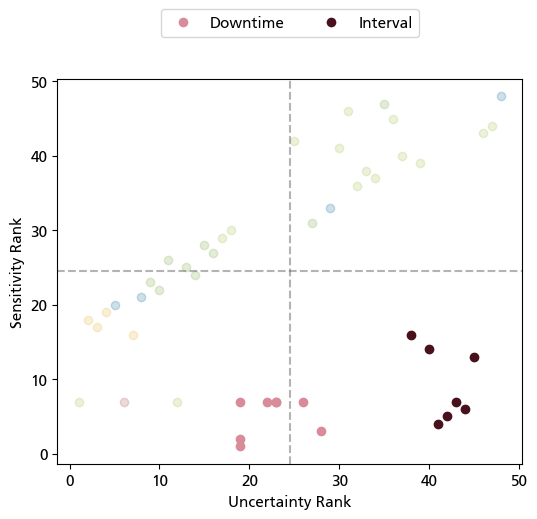

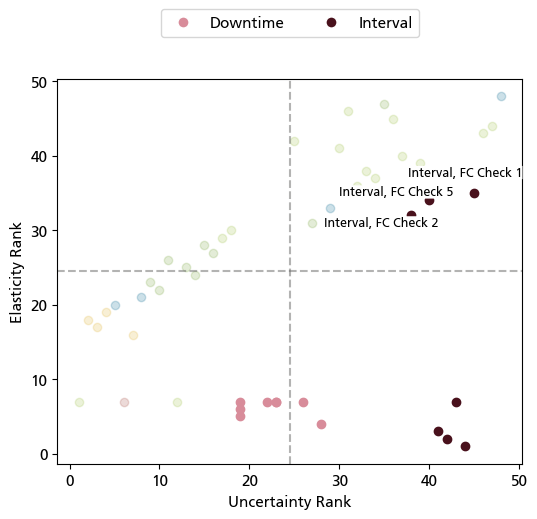

In [31]:
from adjustText import adjust_text

# Define color mapping for lifecycle phases
colors = {
    'Aircraft Production': blue,
    'BoP Production': blue,
    'Air Freight': blue,
    'Kerosene Production': blue,
    'Very Short Haul Flight': yellow,
    'Short Haul Flight': yellow,
    'Medium Haul Flight': yellow,
    'Long Haul Flight': yellow,
    'A-Check': light_green,
    'APU Shop Visit': light_green,
    'C-Check': light_green,
    'D-Check': light_green,
    'Daily Check': light_green,
    'Full Overhaul': light_green,
    'Hot Section Inspection': light_green,
    'Exc. of Compressor': light_green,
    'Exc. of Fan': light_green,
    'Exc. of HPT': light_green,
    'Exc. of LPT': light_green,
    'Landing Gear Shop': light_green,
    'Pre-Flight Check': light_green,
    'Aircraft Transport': light_green,
    'Weekly Check': light_green,
    'Electricity Production': red,
    'Fuel Cell Check 1': green,
    'Fuel Cell Check 2': green,
    'Fuel Cell Check 3': green,
    'Fuel Cell Check 4': green,
    'Fuel Cell Check 5': green,
    'Fuel Cell Check 6': green,
    'Fuel Cell Check 7': green,
    'Fuel Cell Replacement': green,
    'FC Stack Production': green,
    'Downtime, FC Check 1': pink,
    'Downtime, FC Check 2': pink,
    'Downtime, FC Check 3': pink,
    'Downtime, FC Check 4': pink,
    'Downtime, FC Check 5': pink,
    'Downtime, FC Check 6': pink,
    'Downtime, FC Check 7': pink,
    'Downtime, FC Replacement': pink,
    'Interval, FC Check 1': purple,
    'Interval, FC Check 2': purple,
    'Interval, FC Check 3': purple,
    'Interval, FC Check 4': purple,
    'Interval, FC Check 5': purple,
    'Interval, FC Check 6': purple,
    'Interval, FC Check 7': purple,
    'Interval, FC Replacement': purple
}

# Map lifecycle phases to a color legend
lifecycle_phase_colors = {
    # 'Production': blue,
    # 'Flight Operations': yellow,
    # 'Maintenance': green,
    # 'End-of-Life': red,
    'Downtime': pink,
    'Interval': purple
}

# Plotting loop
for impact_category in impact_categories[:1]:
    sensitivity_values = [param['sensitivity'][impact_category]['FC'] for param in parameters_sliced]
    elasticity_values = [param['elasticity'][impact_category]['FC'] for param in parameters_sliced]
    uncertainty_values = [param['std'][impact_category] for param in parameters_sliced]
    
    sensitivity_ranks = pd.Series(sensitivity_values).rank(method="min").tolist()
    elasticity_ranks = pd.Series(elasticity_values).rank(method="min").tolist()
    uncertainty_ranks = pd.Series(uncertainty_values).rank(method="min").tolist()
    
    plt.figure(figsize=(6, 5))

    # create a red line in the middle of x and y axis that is transparent
    plt.axvline(x=24.5, color=gray, linestyle='--', alpha=0.5)
    plt.axhline(y=24.5, color=gray, linestyle='--', alpha=0.5)
    
    # Scatter plot with ranks and assign colors
    texts = []
    for i, parameter in enumerate(parameters_sliced):
        color = colors.get(parameter['name_plots_short'], 'black')
        if 'Downtime' in parameter['name_plots_short'] or 'Interval' in parameter['name_plots_short']:
            plt.scatter(uncertainty_ranks[i], sensitivity_ranks[i], c=color)
            # text = plt.text(uncertainty_ranks[i], sensitivity_ranks[i], parameter['name_plots_short'], fontsize=9, ha='center', va='bottom',
            #                 bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.01'))
            # texts.append(text)
        else:
            plt.scatter(uncertainty_ranks[i], elasticity_ranks[i], c=color, alpha=0.2)
    
    # Add legend above plot
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=phase, markersize=8, markerfacecolor=color)
               for phase, color in lifecycle_phase_colors.items()]
    plt.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=2)

    plt.xlabel('Uncertainty Rank')
    plt.ylabel('Sensitivity Rank')
    
        
    # Adjust text to avoid overlaps
    adjust_text(texts, expand_text=(1.2, 1), expand_points=(1.7, 1.7), force_text=0.2)

    plt.savefig(f"lyfe_2_diagnostic_diagram_sensitivity_maintenance.png", dpi=600, bbox_inches='tight')
    plt.show()
    
    plt.figure(figsize=(6, 5))
    
    # create a red line in the middle of x and y axis that is transparent
    plt.axvline(x=24.5, color=gray, linestyle='--', alpha=0.5)
    plt.axhline(y=24.5, color=gray, linestyle='--', alpha=0.5)

    # Scatter plot with ranks and assign colors
    texts = []
    for i, parameter in enumerate(parameters_sliced):
        color = colors.get(parameter['name_plots_short'], 'black')
        if 'Downtime' in parameter['name_plots_short'] or 'Interval' in parameter['name_plots_short']:
            plt.scatter(uncertainty_ranks[i], elasticity_ranks[i], c=color)
            if elasticity_ranks[i] > 25:
                text = plt.text(uncertainty_ranks[i], elasticity_ranks[i], parameter['name_plots_short'], fontsize=9, ha='center', va='bottom',
                                bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.01'))
                texts.append(text)
        else:
            plt.scatter(uncertainty_ranks[i], elasticity_ranks[i], c=color, alpha=0.2)
    
    # Add legend above plot
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=phase, markersize=8, markerfacecolor=color)
               for phase, color in lifecycle_phase_colors.items()]
    plt.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=2)

    plt.xlabel('Uncertainty Rank')
    plt.ylabel('Elasticity Rank')
        
    # Adjust text to avoid overlaps
    adjust_text(texts, expand_text=(1.2, 1), expand_points=(1.7, 1.7), force_text=0.2)

    plt.savefig(f"lyfe_2_diagnostic_diagram_elasticity_maintenance.png", dpi=600, bbox_inches='tight')
    plt.show()
